In [165]:
import quandl as q
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from datetime import datetime
import requests
import seaborn as sns
import json
import pandas_ta as pta
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import pickle

In [166]:
#url = 'https://www.alphavantage.co/query?function=TIME_SERIES_INTRADAY&symbol=TSCO.LON&interval=1min&apikey=N9ZDIMEAG4EWZ5R3'
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=TSCO.LON&outputsize=full&apikey=PRM5QPCPBWTCTX5I'
#url = 'https://www.alphavantage.co/query?function=HISTORICAL_OPTIONS&symbol=TSCO.LON&apikey=N9ZDIMEAG4EWZ5R3'

r = requests.get(url)
data = r.json()

print(data)

{'Meta Data': {'1. Information': 'Daily Prices (open, high, low, close) and Volumes', '2. Symbol': 'TSCO.LON', '3. Last Refreshed': '2024-12-12', '4. Output Size': 'Full size', '5. Time Zone': 'US/Eastern'}, 'Time Series (Daily)': {'2024-12-12': {'1. open': '369.7000', '2. high': '371.7500', '3. low': '366.8000', '4. close': '370.6000', '5. volume': '8560243'}, '2024-12-11': {'1. open': '366.9000', '2. high': '371.8000', '3. low': '366.8000', '4. close': '370.2000', '5. volume': '31375391'}, '2024-12-10': {'1. open': '365.6000', '2. high': '370.3000', '3. low': '365.4000', '4. close': '368.6000', '5. volume': '25395230'}, '2024-12-09': {'1. open': '367.2000', '2. high': '368.4000', '3. low': '363.9000', '4. close': '364.8000', '5. volume': '7971825'}, '2024-12-06': {'1. open': '374.2000', '2. high': '374.7000', '3. low': '366.9000', '4. close': '366.9000', '5. volume': '37731391'}, '2024-12-05': {'1. open': '375.3000', '2. high': '375.3000', '3. low': '371.6000', '4. close': '374.5000'

In [167]:
url1 = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=TSCO.LON&outputsize=full&apikey=PRM5QPCPBWTCTX5I&datatype=csv'
#url1 = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY_ADJUSTED&symbol=TSCO.LON&outputsize=full&apikey=demo&datatype=csv'

In [168]:
url1

'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=TSCO.LON&outputsize=full&apikey=PRM5QPCPBWTCTX5I&datatype=csv'

In [169]:
url2 = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=NYSE:WIT&outputsize=full&apikey=PRM5QPCPBWTCTX5I&datatype=csv'
url2

'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=NYSE:WIT&outputsize=full&apikey=PRM5QPCPBWTCTX5I&datatype=csv'

In [170]:
df = pd.read_csv('C:/Users/Srik3/OneDrive/Documents/Assessments/CyberCore IT/daily_TSCO.LON.csv')
df

,timestamp,open,high,low,close,volume
0,2024-12-12,369.7000,371.7500,366.8000,370.6000,8560243
1,2024-12-11,366.9000,371.8000,366.8000,370.2000,31375391
2,2024-12-10,365.6000,370.3000,365.4000,368.6000,25395230
3,2024-12-09,367.2000,368.4000,363.9000,364.8000,7971825
4,2024-12-06,374.2000,374.7000,366.9000,366.9000,37731391
...,...,...,...,...,...,...
5036,2005-01-10,319.7501,320.5001,319.0001,320.2501,11117302
5037,2005-01-07,317.7501,321.2501,317.7501,319.7501,37111214
5038,2005-01-06,315.0001,320.0001,314.7501,318.7501,17598422
5039,2005-01-05,315.5001,318.0001,315.0001,315.0001,28205028


In [171]:
df = df.sort_values(by='timestamp', ascending=True)

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5041 entries, 5040 to 0
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  5041 non-null   object 
 1   open       5041 non-null   float64
 2   high       5041 non-null   float64
 3   low        5041 non-null   float64
 4   close      5041 non-null   float64
 5   volume     5041 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 275.7+ KB


In [173]:
df.rename(columns = {'timestamp':'date'}, inplace = True)
df

,date,open,high,low,close,volume
5040,2005-01-04,319.2501,321.2501,317.0001,318.0001,35678243
5039,2005-01-05,315.5001,318.0001,315.0001,315.0001,28205028
5038,2005-01-06,315.0001,320.0001,314.7501,318.7501,17598422
5037,2005-01-07,317.7501,321.2501,317.7501,319.7501,37111214
5036,2005-01-10,319.7501,320.5001,319.0001,320.2501,11117302
...,...,...,...,...,...,...
4,2024-12-06,374.2000,374.7000,366.9000,366.9000,37731391
3,2024-12-09,367.2000,368.4000,363.9000,364.8000,7971825
2,2024-12-10,365.6000,370.3000,365.4000,368.6000,25395230
1,2024-12-11,366.9000,371.8000,366.8000,370.2000,31375391


In [174]:
df['date'] = pd.to_datetime(df['date'])

In [175]:
"""
df['date_day'] = df['date'].dt.strftime('%Y-%m-%d (%A)')
plt.figure(figsize=(12, 6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%A'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.plot(df['date'], df['close'], label="Historical Prices", color="blue")
"""

'\ndf[\'date_day\'] = df[\'date\'].dt.strftime(\'%Y-%m-%d (%A)\')\nplt.figure(figsize=(12, 6))\nplt.gca().xaxis.set_major_formatter(mdates.DateFormatter(\'%Y-%m-%d\n%A\'))\nplt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())\nplt.xticks(rotation=45)\nplt.plot(df[\'date\'], df[\'close\'], label="Historical Prices", color="blue")\n'

In [176]:
df

,date,open,high,low,close,volume
5040,2005-01-04,319.2501,321.2501,317.0001,318.0001,35678243
5039,2005-01-05,315.5001,318.0001,315.0001,315.0001,28205028
5038,2005-01-06,315.0001,320.0001,314.7501,318.7501,17598422
5037,2005-01-07,317.7501,321.2501,317.7501,319.7501,37111214
5036,2005-01-10,319.7501,320.5001,319.0001,320.2501,11117302
...,...,...,...,...,...,...
4,2024-12-06,374.2000,374.7000,366.9000,366.9000,37731391
3,2024-12-09,367.2000,368.4000,363.9000,364.8000,7971825
2,2024-12-10,365.6000,370.3000,365.4000,368.6000,25395230
1,2024-12-11,366.9000,371.8000,366.8000,370.2000,31375391


In [177]:
#df.set_index(["timestamp"], inplace = True) 
df.set_index(["date"], inplace = True) 

In [178]:
df

,open,high,low,close,volume
date,,,,,
2005-01-04,319.2501,321.2501,317.0001,318.0001,35678243
2005-01-05,315.5001,318.0001,315.0001,315.0001,28205028
2005-01-06,315.0001,320.0001,314.7501,318.7501,17598422
2005-01-07,317.7501,321.2501,317.7501,319.7501,37111214
2005-01-10,319.7501,320.5001,319.0001,320.2501,11117302
...,...,...,...,...,...
2024-12-06,374.2000,374.7000,366.9000,366.9000,37731391
2024-12-09,367.2000,368.4000,363.9000,364.8000,7971825
2024-12-10,365.6000,370.3000,365.4000,368.6000,25395230


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5041 entries, 2005-01-04 to 2024-12-12
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5041 non-null   float64
 1   high    5041 non-null   float64
 2   low     5041 non-null   float64
 3   close   5041 non-null   float64
 4   volume  5041 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 236.3 KB


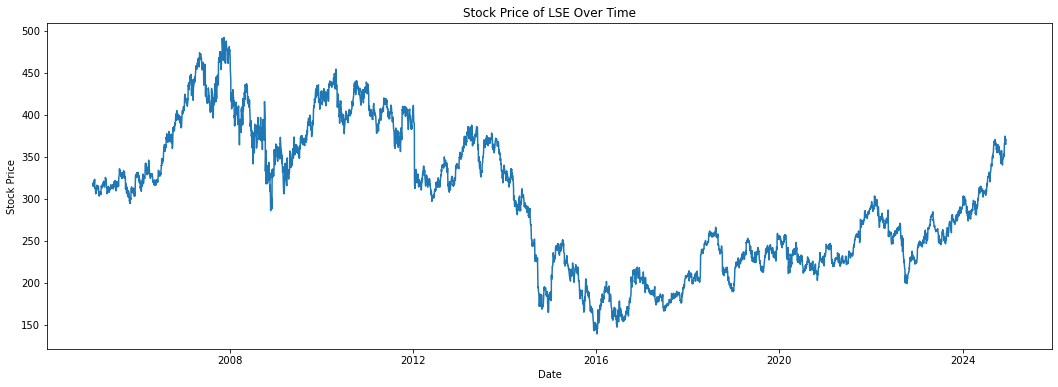

In [180]:
plt.figure(figsize=(18,6))
plt.plot(df.index, df['close'])
#plt.plot(df.index, bpcl_data['Close'])
plt.title('Stock Price of LSE Over Time')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.show()

In [181]:
df['mov_avg'] = df['close'].rolling(window=10).mean()
df['rsi'] = pta.rsi(df['close'], length = 9)
df['middle_band'] = df['close'].rolling(window=10).mean()
df['upper_band'] = df['middle_band'] + 2 * df['close'].rolling(window=10).std()
df['lower_band'] = df['middle_band'] - 2 * df['close'].rolling(window=10).std()

In [182]:
df

,open,high,low,close,volume,mov_avg,rsi,middle_band,upper_band,lower_band
date,,,,,,,,,,
2005-01-04,319.2501,321.2501,317.0001,318.0001,35678243,NaN,NaN,NaN,NaN,NaN
2005-01-05,315.5001,318.0001,315.0001,315.0001,28205028,NaN,NaN,NaN,NaN,NaN
2005-01-06,315.0001,320.0001,314.7501,318.7501,17598422,NaN,NaN,NaN,NaN,NaN
2005-01-07,317.7501,321.2501,317.7501,319.7501,37111214,NaN,NaN,NaN,NaN,NaN
2005-01-10,319.7501,320.5001,319.0001,320.2501,11117302,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2024-12-06,374.2000,374.7000,366.9000,366.9000,37731391,364.53,61.083772,364.53,381.217467,347.842533
2024-12-09,367.2000,368.4000,363.9000,364.8000,7971825,365.79,56.489437,365.79,380.068640,351.511360
2024-12-10,365.6000,370.3000,365.4000,368.6000,25395230,367.61,62.266888,367.61,376.958773,358.261227


In [183]:
df = df.dropna()

In [184]:
df

,open,high,low,close,volume,mov_avg,rsi,middle_band,upper_band,lower_band
date,,,,,,,,,,
2005-01-17,319.5001,323.2501,316.0001,323.2501,33045237,318.2501,65.579006,318.2501,324.152077,312.348123
2005-01-18,316.5001,317.5001,312.0001,313.7501,61830538,317.8251,41.091987,317.8251,324.382750,311.267450
2005-01-19,314.2501,314.5001,311.2501,312.5001,49064616,317.5751,38.939689,317.5751,324.770971,310.379229
2005-01-20,311.7501,314.2501,311.0001,313.5001,27584607,317.0501,41.688483,317.0501,324.621244,309.478956
2005-01-21,314.7501,314.7501,312.0001,312.2501,25807043,316.3001,39.206473,316.3001,324.162811,308.437389
...,...,...,...,...,...,...,...,...,...,...
2024-12-06,374.2000,374.7000,366.9000,366.9000,37731391,364.5300,61.083772,364.5300,381.217467,347.842533
2024-12-09,367.2000,368.4000,363.9000,364.8000,7971825,365.7900,56.489437,365.7900,380.068640,351.511360
2024-12-10,365.6000,370.3000,365.4000,368.6000,25395230,367.6100,62.266888,367.6100,376.958773,358.261227


In [185]:
df.to_csv("datasets/daily_TSCO.LON.csv", index=True)

<AxesSubplot:>

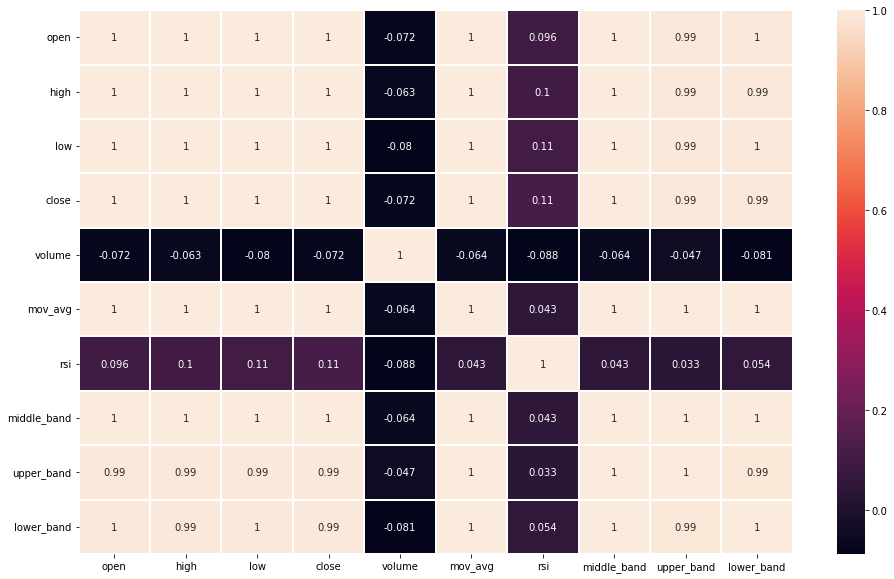

In [186]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(16, 10))

#create heatmap
sns.heatmap(corr, annot=True, linewidths=.3)

In [187]:
#Feature Selection
#X = df[['open', 'high', 'low', 'close']]
#X = df[['open', 'high', 'low', 'volume']]

X = df[['open', 'high', 'low', 'close', 'mov_avg', 'middle_band', 'upper_band', 'lower_band']]
y = df['close']

In [188]:
#Data Scaling
#scaler = MinMaxScaler(feature_range = (0,1))
#scaler = MinMaxScaler()
#X_scaled = scaler.fit_transform(X)

In [189]:
#X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2)

In [190]:
#scaler = StandardScaler()
#X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train an XGBoost model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, booster='gbtree')
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Add predicted prices to test data
predicted_prices = X_test.copy()
#predicted_prices['Close'] = y_pred

In [191]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("Mean squared error:", mse)
print("Mean absolute error:", mae)
print("R-squared:", r2)

Mean squared error: 0.4196821674691631
Mean absolute error: 0.42063052882750335
R-squared: 0.9999388385832401


In [192]:
next_day = X.tail(1)
next_day_pred = model.predict(next_day)
next_day_close = next_day_pred[0]
print("Next day predicted close:", next_day_close)

Next day predicted close: 370.35748


In [193]:
param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [None, 10, 20],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

xg = xgb.XGBRegressor(random_state=42)

grid_search = GridSearchCV(estimator=xg, param_grid=param_grid,
                           cv=5, scoring = 'neg_mean_squared_error',
                           verbose=2, n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("best parameters: ", best_params)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error: ", mse)
print("R2 Score:", r2)

"""
plt.figure(figsize=(18, 6))
plt.plot(y_test, label='Actual Values', color='blue')
plt.plot(y_pred, label='Predicted Values', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Stock Price')
plt.title('Actual vs. Predicted Stock Prices')
plt.legend()
plt.show()
"""

Fitting 5 folds for each of 81 candidates, totalling 405 fits


C:\Users\Srik3\anaconda3\envs\aud\lib\site-packages\xgboost\core.py:158: UserWarning: [17:39:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)


best parameters:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mean Squared Error:  0.4196821674691631
R2 Score: 0.9999388385832401


"\nplt.figure(figsize=(18, 6))\nplt.plot(y_test, label='Actual Values', color='blue')\nplt.plot(y_pred, label='Predicted Values', color='red')\nplt.xlabel('Sample Index')\nplt.ylabel('Stock Price')\nplt.title('Actual vs. Predicted Stock Prices')\nplt.legend()\nplt.show()\n"

In [194]:
import joblib
joblib.dump(model, 'xg_model.pkl')

['xg_model.pkl']

# NYSE DATA

# Actual code

In [195]:
df2 = pd.read_csv('C:/Users/Srik3/OneDrive/Documents/Assessments/CyberCore IT/daily_NYSE_WIT.csv')

In [196]:
df2 = df2.sort_values(by='timestamp', ascending=True)

In [197]:
df2

,timestamp,open,high,low,close,volume
6074,2000-10-19,44.50,49.310,41.370,49.25,2077100
6073,2000-10-20,49.25,53.310,48.880,52.75,793550
6072,2000-10-23,52.50,52.500,47.380,48.37,323850
6071,2000-10-24,48.62,49.500,48.370,48.88,186080
6070,2000-10-25,48.69,49.250,48.500,48.81,150660
...,...,...,...,...,...,...
4,2024-12-06,7.22,7.225,6.940,6.98,4906549
3,2024-12-09,7.20,7.290,7.160,7.18,3086206
2,2024-12-10,7.24,7.300,7.195,7.24,1884384
1,2024-12-11,3.69,3.750,3.580,3.62,4703945


In [198]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6075 entries, 6074 to 0
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  6075 non-null   object 
 1   open       6075 non-null   float64
 2   high       6075 non-null   float64
 3   low        6075 non-null   float64
 4   close      6075 non-null   float64
 5   volume     6075 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 332.2+ KB


In [199]:
df2.rename(columns = {'timestamp':'date'}, inplace = True)
df2

,date,open,high,low,close,volume
6074,2000-10-19,44.50,49.310,41.370,49.25,2077100
6073,2000-10-20,49.25,53.310,48.880,52.75,793550
6072,2000-10-23,52.50,52.500,47.380,48.37,323850
6071,2000-10-24,48.62,49.500,48.370,48.88,186080
6070,2000-10-25,48.69,49.250,48.500,48.81,150660
...,...,...,...,...,...,...
4,2024-12-06,7.22,7.225,6.940,6.98,4906549
3,2024-12-09,7.20,7.290,7.160,7.18,3086206
2,2024-12-10,7.24,7.300,7.195,7.24,1884384
1,2024-12-11,3.69,3.750,3.580,3.62,4703945


In [200]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6075 entries, 6074 to 0
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    6075 non-null   object 
 1   open    6075 non-null   float64
 2   high    6075 non-null   float64
 3   low     6075 non-null   float64
 4   close   6075 non-null   float64
 5   volume  6075 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 332.2+ KB


In [201]:
df2['date'] = pd.to_datetime(df2['date'])

In [202]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6075 entries, 6074 to 0
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    6075 non-null   datetime64[ns]
 1   open    6075 non-null   float64       
 2   high    6075 non-null   float64       
 3   low     6075 non-null   float64       
 4   close   6075 non-null   float64       
 5   volume  6075 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 332.2 KB


In [203]:
df2.set_index(["date"], inplace = True) 

In [204]:
df2

,open,high,low,close,volume
date,,,,,
2000-10-19,44.50,49.310,41.370,49.25,2077100
2000-10-20,49.25,53.310,48.880,52.75,793550
2000-10-23,52.50,52.500,47.380,48.37,323850
2000-10-24,48.62,49.500,48.370,48.88,186080
2000-10-25,48.69,49.250,48.500,48.81,150660
...,...,...,...,...,...
2024-12-06,7.22,7.225,6.940,6.98,4906549
2024-12-09,7.20,7.290,7.160,7.18,3086206
2024-12-10,7.24,7.300,7.195,7.24,1884384


In [205]:
#df2.to_csv("daily_NYSE_WIT.csv", index=True)

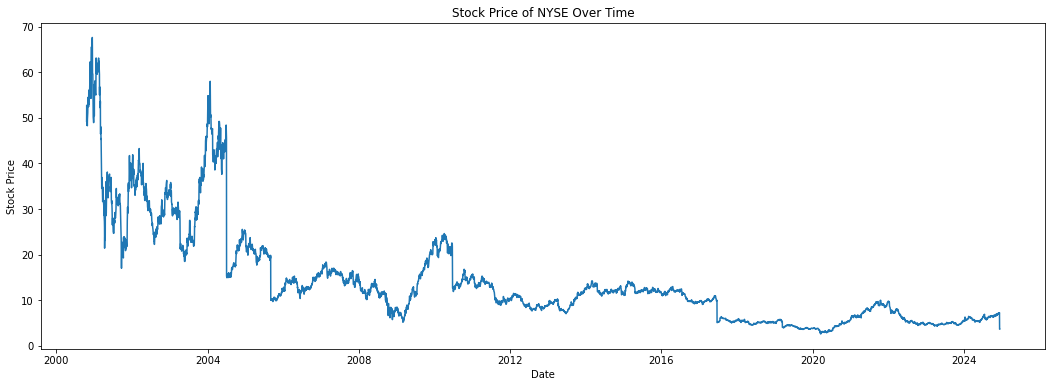

In [206]:
plt.figure(figsize=(18,6))
plt.plot(df2.index, df2['close'])
#plt.plot(df.index, bpcl_data['Close'])
#ticks = [data_date[i] if ((i%config["plots"]["xticks_interval"]==0 and (num_data_points-i) > config["plots"]["xticks_interval"]) or i==num_data_points-1) else None for i in range(num_data_points)] # make x ticks nice
#plt.xticks(df2.index, xticks, rotation='vertical')

plt.title('Stock Price of NYSE Over Time')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.show()

In [207]:
df2['mov_avg'] = df2['close'].rolling(window=10).mean()

In [208]:
df2.head(20)

,open,high,low,close,volume,mov_avg
date,,,,,,
2000-10-19,44.50,49.31,41.37,49.25,2077100,NaN
2000-10-20,49.25,53.31,48.88,52.75,793550,NaN
2000-10-23,52.50,52.50,47.38,48.37,323850,NaN
2000-10-24,48.62,49.50,48.37,48.88,186080,NaN
2000-10-25,48.69,49.25,48.50,48.81,150660,NaN
2000-10-26,48.94,49.25,47.31,48.25,102570,NaN
2000-10-27,48.50,49.94,48.50,49.75,149980,NaN
2000-10-30,49.75,52.00,49.62,51.06,204910,NaN
2000-10-31,51.31,54.25,51.31,52.63,194820,NaN


In [209]:
df2['rsi'] = pta.rsi(df2['close'], length = 9)

In [210]:
df2.head(20)

,open,high,low,close,volume,mov_avg,rsi
date,,,,,,,
2000-10-19,44.50,49.31,41.37,49.25,2077100,NaN,NaN
2000-10-20,49.25,53.31,48.88,52.75,793550,NaN,NaN
2000-10-23,52.50,52.50,47.38,48.37,323850,NaN,NaN
2000-10-24,48.62,49.50,48.37,48.88,186080,NaN,NaN
2000-10-25,48.69,49.25,48.50,48.81,150660,NaN,NaN
2000-10-26,48.94,49.25,47.31,48.25,102570,NaN,NaN
2000-10-27,48.50,49.94,48.50,49.75,149980,NaN,NaN
2000-10-30,49.75,52.00,49.62,51.06,204910,NaN,NaN
2000-10-31,51.31,54.25,51.31,52.63,194820,NaN,NaN


In [211]:
df2['middle_band'] = df2['close'].rolling(window=10).mean()
df2['upper_band'] = df2['middle_band'] + 2 * df2['close'].rolling(window=10).std()
df2['lower_band'] = df2['middle_band'] - 2 * df2['close'].rolling(window=10).std()
df2

,open,high,low,close,volume,mov_avg,rsi,middle_band,upper_band,lower_band
date,,,,,,,,,,
2000-10-19,44.50,49.310,41.370,49.25,2077100,NaN,NaN,NaN,NaN,NaN
2000-10-20,49.25,53.310,48.880,52.75,793550,NaN,NaN,NaN,NaN,NaN
2000-10-23,52.50,52.500,47.380,48.37,323850,NaN,NaN,NaN,NaN,NaN
2000-10-24,48.62,49.500,48.370,48.88,186080,NaN,NaN,NaN,NaN,NaN
2000-10-25,48.69,49.250,48.500,48.81,150660,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2024-12-06,7.22,7.225,6.940,6.98,4906549,7.063,50.553303,7.063,7.211788,6.914212
2024-12-09,7.20,7.290,7.160,7.18,3086206,7.083,61.188261,7.083,7.235912,6.930088
2024-12-10,7.24,7.300,7.195,7.24,1884384,7.100,63.814909,7.100,7.281598,6.918402


In [212]:
df2 = df2.dropna()

In [213]:
df2

,open,high,low,close,volume,mov_avg,rsi,middle_band,upper_band,lower_band
date,,,,,,,,,,
2000-11-01,52.75,53.880,52.750,53.00,84740,50.275,70.317477,50.275,54.096672,46.453328
2000-11-02,52.87,54.250,52.870,54.25,86760,50.775,74.861980,50.775,55.252680,46.297320
2000-11-03,54.38,55.750,54.310,54.50,124430,50.950,75.699105,50.950,55.884252,46.015748
2000-11-06,54.50,54.560,52.870,52.87,98530,51.400,60.838461,51.400,56.103918,46.696082
2000-11-07,52.87,53.000,52.130,52.44,62100,51.756,57.489073,51.756,56.140277,47.371723
...,...,...,...,...,...,...,...,...,...,...
2024-12-06,7.22,7.225,6.940,6.98,4906549,7.063,50.553303,7.063,7.211788,6.914212
2024-12-09,7.20,7.290,7.160,7.18,3086206,7.083,61.188261,7.083,7.235912,6.930088
2024-12-10,7.24,7.300,7.195,7.24,1884384,7.100,63.814909,7.100,7.281598,6.918402


In [214]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6066 entries, 2000-11-01 to 2024-12-12
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   open         6066 non-null   float64
 1   high         6066 non-null   float64
 2   low          6066 non-null   float64
 3   close        6066 non-null   float64
 4   volume       6066 non-null   int64  
 5   mov_avg      6066 non-null   float64
 6   rsi          6066 non-null   float64
 7   middle_band  6066 non-null   float64
 8   upper_band   6066 non-null   float64
 9   lower_band   6066 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 521.3 KB


In [215]:
df2.to_csv("daily_NYSE_WIT.csv", index=True)

<AxesSubplot:>

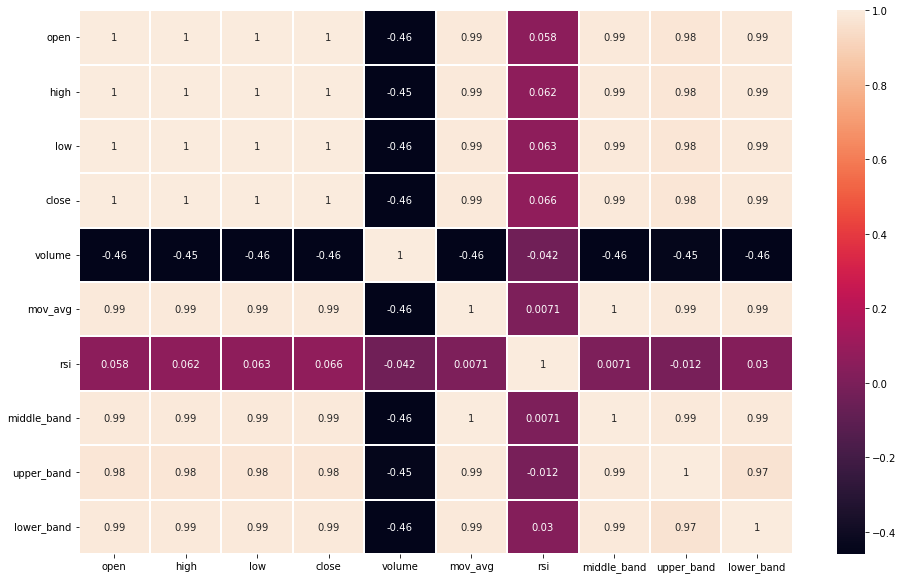

In [216]:
corr = df2.corr()
fig, ax = plt.subplots(figsize=(16, 10))

#create heatmap
sns.heatmap(corr, annot=True, linewidths=.3)

In [217]:
#X = df2[['RSI', 'Middle_Band', 'Upper_Band', 'Lower_Band']]
#X = df2[['open', 'high', 'low', 'close', 'volume']]

X = df2[['open', 'high', 'low', 'close', 'mov_avg', 'middle_band', 'upper_band', 'lower_band']]
y = df2['close']

#scaler = MinMaxScaler(feature_range = (0,1))
#X_scaled = scaler.fit_transform(X)

#scaler = MinMaxScaler()
#X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [218]:
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, booster='gbtree')
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Square Error: ", mse)
print("Mean Absolute Error: ", mae)

Mean Square Error:  0.05720883841718621
Mean Absolute Error:  0.07483591564404707


In [219]:
next_day = X.tail(1)
next_day_pred = model.predict(next_day)
next_day_close = next_day_pred[0]
print("Next day predicted close:", next_day_close)

Next day predicted close: 3.6233628


In [220]:
import joblib
joblib.dump(model, 'xg1_model.pkl')

['xg1_model.pkl']

In [221]:
param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [None, 10, 20],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

#rf = RandomForestRegressor(random_state=42)
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, booster='gbtree')

grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           cv=5, scoring = 'neg_mean_squared_error',
                           verbose=2, n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("best parameters: ", best_params)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error: ", mse)
print("R2 Score:", r2)

"""
plt.figure(figsize=(18, 6))
plt.plot(y_test, label='Actual Values', color='blue')
plt.plot(y_pred, label='Predicted Values', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Stock Price')
plt.title('Actual vs. Predicted Stock Prices')
plt.legend()
plt.show()
"""

Fitting 5 folds for each of 81 candidates, totalling 405 fits


C:\Users\Srik3\anaconda3\envs\aud\lib\site-packages\xgboost\core.py:158: UserWarning: [17:42:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)


best parameters:  {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Mean Squared Error:  0.05818472706483469
R2 Score: 0.9995299569709595


"\nplt.figure(figsize=(18, 6))\nplt.plot(y_test, label='Actual Values', color='blue')\nplt.plot(y_pred, label='Predicted Values', color='red')\nplt.xlabel('Sample Index')\nplt.ylabel('Stock Price')\nplt.title('Actual vs. Predicted Stock Prices')\nplt.legend()\nplt.show()\n"